<a href="https://colab.research.google.com/github/Eddythemachine/intro_to_cnn/blob/main/multiclass_classification_with_nueral_net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORT LIB

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as im
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

# Intro Working with Multiclass Classification


In [2]:
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
train_data = train_data / 255.0
test_data = test_data / 255.0

In [4]:
# Create validation set from training data
val_size = int(0.2 * len(train_data))

val_data = train_data[:val_size]
val_labels = train_labels[:val_size]

train_data = train_data[val_size:]
train_labels = train_labels[val_size:]

In [5]:
print(f"Training Sample \n {train_data}")
print(f"Training Labels {train_labels}")

Training Sample 
 [[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0

In [6]:
train_data[0].shape, train_labels[0]

((28, 28), np.uint8(6))

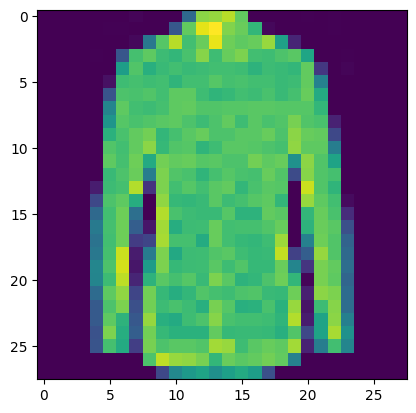

In [7]:
# Plot sample
plt.imshow(train_data[0])

In [8]:
# Check our samples labels
train_labels[0]

np.uint8(6)

In [9]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(class_names)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


Text(0.5, 1.0, 'Dress')

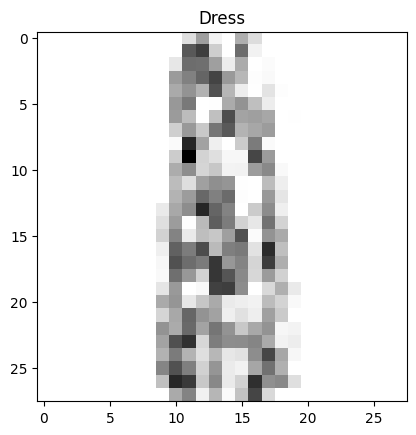

In [10]:
index_of_choice = 10
plt.imshow(train_data[10], cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])

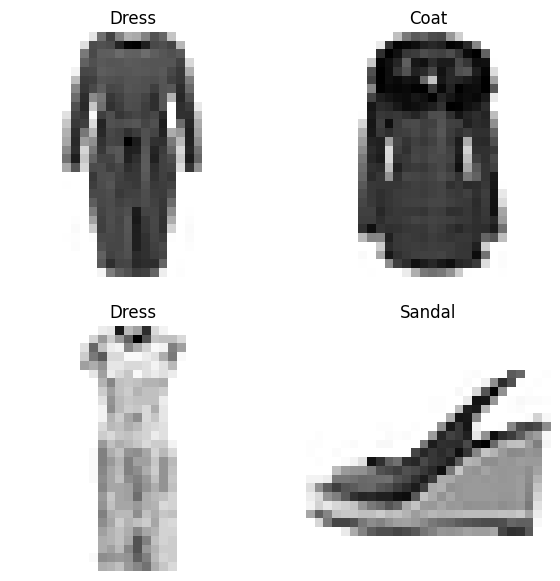

In [11]:
# Plot multiple images
import random

plt.figure(figsize=(7,7))
for i in range(4):
    ax = plt.subplot(2,2, i+1)
    rand_index = random.choice(range(len(train_data)))
    plt.imshow(train_data[rand_index], cmap=plt.cm.binary)
    plt.title(class_names[train_labels[rand_index]])
    plt.axis("off")

In [12]:
train_data[0].shape

(28, 28)

In [13]:
model_1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(train_data[0].shape)),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dense(10, activation="softmax")
])

In [14]:
model_1.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [15]:
# Early stop
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [16]:
history_1 = model_1.fit(
    train_data,
    train_labels,
    validation_data=(val_data, val_labels),
    epochs=100,
    callbacks=[early_stop],
    batch_size=32
)

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7634 - loss: 0.9343 - val_accuracy: 0.8370 - val_loss: 0.6548
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8090 - loss: 0.7096 - val_accuracy: 0.8466 - val_loss: 0.5709
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8139 - loss: 0.6491 - val_accuracy: 0.8441 - val_loss: 0.5370
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8126 - loss: 0.6311 - val_accuracy: 0.8392 - val_loss: 0.5515
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8163 - loss: 0.6099 - val_accuracy: 0.7319 - val_loss: 0.9800
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8195 - loss: 0.5936 - val_accuracy: 0.8459 - val_loss: 0.5174
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8221 - loss: 0.5818 - val_accuracy: 0.8357 - val_loss: 0.5227
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8223 - loss: 

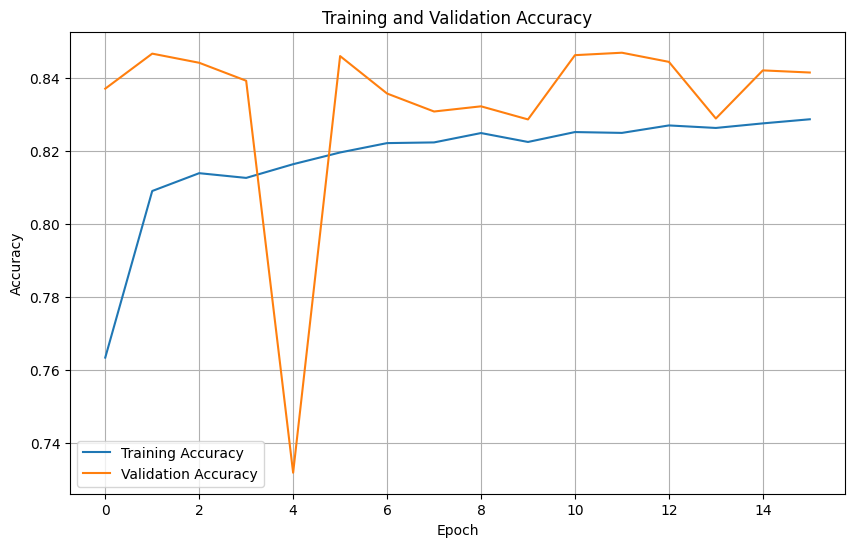

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(history_1.history['accuracy'], label='Training Accuracy')
plt.plot(history_1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
model_1.evaluate(test_data, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8393 - loss: 0.5196


[0.5196238160133362, 0.8392999768257141]